In [1]:
import re
from pathlib import Path

import yt
import numpy as np
import pandas as pd


# =========================
# User settings
# =========================
PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")          # plotfile 所在資料夾
PLOT_PREFIX = "plt"
PLOT_INTERVAL = 100           # 你的 plot_int，例如 100

# 如果你的 field 名稱不是 ("boxlib", "Phi")，後面會自動列出 field_list 方便你改
PHI_FIELD_CANDIDATES = [
    ("boxlib", "Phi"),
    ("boxlib", "phi"),
    ("boxlib", "PoissonPhi"),
    "Phi",
    "phi",
    "PoissonPhi",
]

In [2]:
def get_plot_step(path: Path):
    """
    從 plt00000100 這種檔名取出 100
    """
    m = re.fullmatch(rf"{PLOT_PREFIX}(\d+)", path.name)
    if m is None:
        return None
    return int(m.group(1))


def find_plotfiles():
    """
    找出所有 plt######## 資料夾，並依 step 排序
    """
    plotfiles = []
    for p in PLOT_DIR.iterdir():
        if not p.is_dir():
            continue

        step = get_plot_step(p)
        if step is not None:
            plotfiles.append((step, p))

    plotfiles.sort(key=lambda x: x[0])
    return plotfiles


def find_phi_field(ds):
    """
    自動找 Phi field
    """
    field_list = list(ds.field_list) + list(ds.derived_field_list)

    for cand in PHI_FIELD_CANDIDATES:
        if cand in field_list:
            return cand

    raise RuntimeError(
        "找不到 Phi field。請先看 ds.field_list，然後手動修改 PHI_FIELD_CANDIDATES。\n"
        f"Available fields:\n{ds.field_list}"
    )


def read_top_phi(plotfile: Path):
    """
    讀取 top electrode / top boundary 附近的 Phi 平均值。

    這裡用 domain 最上層一個 cell-thickness 的 slab：
        z in [zmax - dz, zmax]
    取 Phi 平均。
    """
    ds = yt.load(str(plotfile))
    phi_field = find_phi_field(ds)

    zmin = ds.domain_left_edge[2].to_value()
    zmax = ds.domain_right_edge[2].to_value()
    dz = ds.index.get_smallest_dx().to_value()

    xcen = 0.5 * (ds.domain_left_edge[0] + ds.domain_right_edge[0])
    ycen = 0.5 * (ds.domain_left_edge[1] + ds.domain_right_edge[1])
    zcen = ds.domain_right_edge[2] - 0.5 * ds.quan(dz, "code_length")

    width_x = ds.domain_right_edge[0] - ds.domain_left_edge[0]
    width_y = ds.domain_right_edge[1] - ds.domain_left_edge[1]
    width_z = ds.quan(dz, "code_length")

    top_slab = ds.box(
        [
            ds.domain_left_edge[0],
            ds.domain_left_edge[1],
            ds.domain_right_edge[2] - ds.quan(dz, "code_length"),
        ],
        [
            ds.domain_right_edge[0],
            ds.domain_right_edge[1],
            ds.domain_right_edge[2],
        ],
    )

    phi_vals = top_slab[phi_field].to_value()

    return {
        "top_phi_mean": float(np.mean(phi_vals)),
        "top_phi_min": float(np.min(phi_vals)),
        "top_phi_max": float(np.max(phi_vals)),
        "zmax": float(zmax),
        "dz": float(dz),
        "phi_field": str(phi_field),
        "time": float(ds.current_time.to_value()),
    }

In [4]:
ds = yt.load(PLOT_DIR/"plt00005000")  # 先隨便載入一個，看看裡面有哪些 field

print()
print("Current time:", ds.current_time)
print("Domain min coordinate(m) :", ds.domain_left_edge)
print("Domain max coordinate(m) :", ds.domain_right_edge)
print("Domain dimensions(xyz方向各切成幾格):", ds.domain_dimensions)
print()
print("field_list:")
for f in ds.field_list:
    print("  ", f)

print()#換行
print("derived_field_list containing boxlib fields:")
for f in ds.derived_field_list:
    if isinstance(f, tuple) and f[0] == "boxlib":
        print("  ", f)

yt : [INFO     ] 2026-05-24 20:25:47,256 Parameters: current_time              = 1.999999999999879e-09


yt : [INFO     ] 2026-05-24 20:25:47,257 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-05-24 20:25:47,258 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 20:25:47,259 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]



Current time: 1.999999999999879e-09 code_time
Domain min coordinate(m) : [-1.6e-08 -1.6e-08  0.0e+00] code_length
Domain max coordinate(m) : [1.6e-08 1.6e-08 9.0e-09] code_length
Domain dimensions(xyz方向各切成幾格): [64 64 18]

field_list:
   ('boxlib', 'Ex')
   ('boxlib', 'Ey')
   ('boxlib', 'Ez')
   ('boxlib', 'Phi')
   ('boxlib', 'PhiDiff')
   ('boxlib', 'PoissonRHS')
   ('boxlib', 'Px')
   ('boxlib', 'Py')
   ('boxlib', 'Pz')
   ('boxlib', 'alpha')
   ('boxlib', 'beta')
   ('boxlib', 'charge')
   ('boxlib', 'electrons')
   ('boxlib', 'epsilon')
   ('boxlib', 'holes')
   ('boxlib', 'mask')
   ('boxlib', 'theta')
   ('boxlib', 'tphase')

derived_field_list containing boxlib fields:
   ('boxlib', 'Ex')
   ('boxlib', 'Ey')
   ('boxlib', 'Ez')
   ('boxlib', 'Phi')
   ('boxlib', 'PhiDiff')
   ('boxlib', 'PoissonRHS')
   ('boxlib', 'Px')
   ('boxlib', 'Py')
   ('boxlib', 'Pz')
   ('boxlib', 'alpha')
   ('boxlib', 'beta')
   ('boxlib', 'cell_volume')
   ('boxlib', 'charge')
   ('boxlib', 'dx')


yt : [INFO     ] 2026-05-25 17:12:42,664 Parameters: current_time              = 1.999999999999879e-09
yt : [INFO     ] 2026-05-25 17:12:42,665 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-05-25 17:12:42,665 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-25 17:12:42,666 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


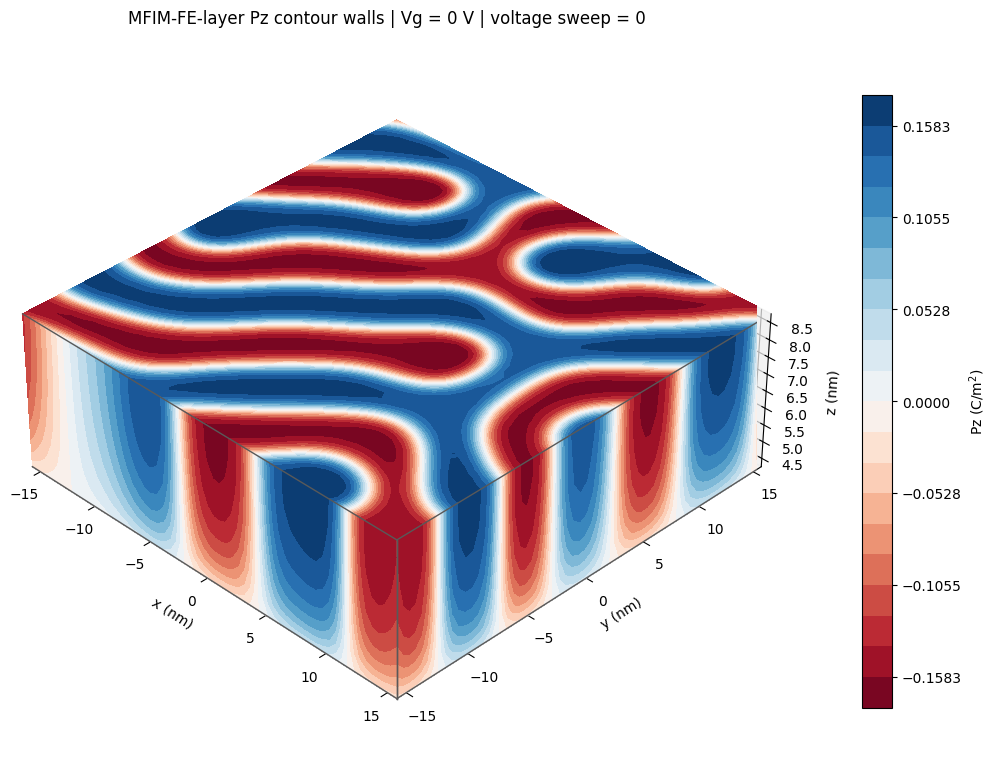

In [2]:
from pathlib import Path

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")
PLOTFILE_NAME = "plt00005000"   # 改成你要畫的 plotfile

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# FE layer range, unit: nm
FE_Z_LO_NM = 4.0
FE_Z_HI_NM = 9.0

# 如果 FE 只想取部分 x/y 範圍
USE_FE_X_RANGE = False
FE_X_LO_NM = -16.0
FE_X_HI_NM = 16.0

USE_FE_Y_RANGE = False
FE_Y_LO_NM = -16.0
FE_Y_HI_NM = 16.0

# contour levels
N_LEVELS = 21

# 視角
ELEV = 35
AZIM = -45

# 色階是否對稱於 0
SYMMETRIC_COLOR_SCALE = True


# ==========================
# Helper
# ==========================

def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


# ==========================
# Load data
# ==========================

plotfile = PLOT_DIR / PLOTFILE_NAME
ds = yt.load(str(plotfile))
g = ds.index.grids[0]

P = to_numpy(g[P_FIELD])

if PHI_FIELD in ds.field_list:
    Phi = to_numpy(g[PHI_FIELD])
else:
    Phi = None

Nx, Ny, Nz = P.shape

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dx = (hi - lo) / np.array([Nx, Ny, Nz])

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9


# ==========================
# Select FE layer
# ==========================

z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

if USE_FE_X_RANGE:
    x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
else:
    x_sel = np.ones_like(x_nm, dtype=bool)

if USE_FE_Y_RANGE:
    y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
else:
    y_sel = np.ones_like(y_nm, dtype=bool)

P_fe = P[np.ix_(x_sel, y_sel, z_sel)]

x_fe = x_nm[x_sel]
y_fe = y_nm[y_sel]
z_fe = z_nm[z_sel]

Nx_fe, Ny_fe, Nz_fe = P_fe.shape

# 選三個切面：
# xy plane at top FE surface
k_top = Nz_fe - 1

# xz plane at y center
j_mid = 0

# yz plane at x max side
i_right = Nx_fe - 1

P_xy = P_fe[:, :, k_top]      # shape (Nx, Ny)
P_xz = P_fe[:, j_mid, :]      # shape (Nx, Nz)
P_yz = P_fe[i_right, :, :]    # shape (Ny, Nz)

# 建立 2D coordinates
X_xy, Y_xy = np.meshgrid(x_fe, y_fe, indexing="ij")
X_xz, Z_xz = np.meshgrid(x_fe, z_fe, indexing="ij")
Y_yz, Z_yz = np.meshgrid(y_fe, z_fe, indexing="ij")


# ==========================
# Voltage label
# ==========================

if Phi is not None:
    top_phi = Phi[:, :, -1]
    Vtop_mean = float(np.mean(top_phi))
else:
    Vtop_mean = np.nan


# ==========================
# Color scale
# ==========================

if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(P_fe))
    vmin = -vmax
else:
    vmin = np.nanmin(P_fe)
    vmax = np.nanmax(P_fe)

levels = np.linspace(vmin, vmax, N_LEVELS)

kw = dict(
    levels=levels,
    vmin=vmin,
    vmax=vmax,
    cmap="RdBu",
)


# ==========================
# Plot 3D contour walls
# ==========================

fig = plt.figure(figsize=(10, 11))
ax = fig.add_subplot(111, projection="3d")

xmin, xmax = x_fe.min(), x_fe.max()
ymin, ymax = y_fe.min(), y_fe.max()
zmin, zmax = z_fe.min(), z_fe.max()

# 1. xy plane, placed at z = zmax
# contourf expects arrays with same shape.
# X_xy/Y_xy/P_xy are (Nx, Ny)
C1 = ax.contourf(
    X_xy,
    Y_xy,
    P_xy,
    zdir="z",
    offset=zmax,
    **kw
)

# 2. xz plane, placed at y = ymin
# Here x-axis is X_xz, vertical is Z_xz, color is P_xz
C2 = ax.contourf(
    X_xz,
    P_xz,
    Z_xz,
    zdir="y",
    offset=ymin,
    **kw
)

# 3. yz plane, placed at x = xmax
# Here horizontal axis is Y_yz, vertical is Z_yz, color is P_yz
C3 = ax.contourf(
    P_yz,
    Y_yz,
    Z_yz,
    zdir="x",
    offset=xmax,
    **kw
)

# Set axis limits
ax.set(
    xlim=[xmin, xmax],
    ylim=[ymin, ymax],
    zlim=[zmin, zmax],
)

# Draw box edges
edges_kw = dict(color="0.35", linewidth=1.0, zorder=1000)

# 只畫可見的外框邊，不畫背後被內容遮住的線
visible_edges = [
    # bottom/front-ish edges
    ([xmin, xmax], [ymin, ymin], [zmin, zmin]),
    ([xmax, xmax], [ymin, ymax], [zmin, zmin]),
    ([xmax, xmax], [ymin, ymin], [zmin, zmax]),

    # top/front-ish edges
    ([xmin, xmax], [ymin, ymin], [zmax, zmax]),
    ([xmax, xmax], [ymin, ymax], [zmax, zmax]),
    ([xmax, xmax], [ymin, ymin], [zmin, zmax]),
]

for xs, ys, zs in visible_edges:
    ax.plot(xs, ys, zs, **edges_kw)

ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_zlabel("z (nm)")

ax.view_init(ELEV, AZIM)
#ax.set_box_aspect((xmax - xmin, ymax - ymin, zmax - zmin))
Z_VISUAL_SCALE = 2.5
ax.set_box_aspect((
    xmax - xmin,
    ymax - ymin,
    Z_VISUAL_SCALE * (zmax - zmin)
))

ax.set_title(
    f"MFIM-FE-layer Pz contour walls | Vg = 0 V | voltage sweep = 0"
)

cbar = fig.colorbar(C3, ax=ax, fraction=0.035, pad=0.12)
cbar.set_label(r"Pz (C/m$^2$)")

plt.tight_layout()
plt.show()